In [1]:
# load librairies
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import os
from os.path import join
import seaborn as sns
import statsmodels.api as sm
import scipy
import json
import statsmodels.formula.api as smf
from collections import defaultdict
from scipy.stats import wilcoxon, ttest_rel

from functions import utils
from functions import plotting
from functions import io

In [2]:
# pick format to save figures : png for quick visualization, pdf for illustrator
save_as = 'png'
color_dict = {
    'DBS ON': '#20a39e', 
    'DBS OFF': '#ef5b5b', 
    'control': '#ffba49', 
    'preop': '#8E7DBE',
    'Session 1': "#206ea1", 
    'Session 2': "#5FA363", 
    }
visualize_by = 'subject' # pick whether to visualize by condition (DBS ON, DBS OFF, control) or by subject id


# 1. Select subjects, create color palette and load data #

In [3]:
# Use the Included or excluded.xlsx document:
onedrive_path = utils._get_onedrive_path()

working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
if not os.path.isdir(behav_results_saving_path):
    os.makedirs(behav_results_saving_path)

# read the json file containing the included and excluded subjects
# Open and read the JSON file
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)    

In [4]:
included_subjects

['C003 mSST',
 'C004 mSST',
 'C006 mSST',
 'C007 mSST',
 'C008 mSST',
 'C009 mSST',
 'C010 mSST',
 'C011 mSST',
 'C012 mSST',
 'C013 mSST',
 'C014 mSST',
 'C015 mSST',
 'sub006 DBS ON mSST',
 'sub006 DBS OFF mSST',
 'sub011 DBS OFF mSST',
 'sub011 DBS ON mSST',
 'sub012 DBS ON mSST',
 'sub012 DBS OFF mSST',
 'sub015 DBS OFF mSST',
 'sub015 DBS ON mSST',
 'sub019 DBS ON mSST',
 'sub019 DBS OFF mSST',
 'sub023 DBS OFF mSST',
 'sub023 DBS ON mSST',
 'sub025 DBS ON mSST',
 'sub025 DBS OFF mSST',
 'sub027 DBS ON mSST',
 'sub027 DBS OFF mSST',
 'sub028 DBS OFF mSST',
 'sub028 DBS ON mSST',
 'sub029 DBS ON mSST',
 'sub029 DBS OFF mSST',
 'sub032 DBS ON mSST',
 'sub032 DBS OFF mSST',
 'sub033 DBS ON mSST',
 'sub033 DBS OFF mSST']

In [5]:
subject_colors = utils.create_color_palette(included_subjects)
utils.plot_color_palette(
    subject_colors = subject_colors,
    save_as='png', 
    saving_path=behav_results_saving_path
    )

['C003', 'C004', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011', 'C012', 'C013', 'C014', 'C015', 'sub006', 'sub011', 'sub012', 'sub015', 'sub019', 'sub023', 'sub025', 'sub027', 'sub028', 'sub029', 'sub032', 'sub033']


In [6]:
# load excel files for all included subjects and extract stats
data = io.load_behav_data(included_subjects, onedrive_path)
stats = utils.extract_stats(data)

C003 mSST
C004 mSST
C006 mSST
C007 mSST
C008 mSST
C009 mSST
C010 mSST
C011 mSST
C012 mSST
C013 mSST
C014 mSST
C015 mSST
sub006 DBS ON mSST
sub006 DBS OFF mSST
sub011 DBS OFF mSST
sub011 DBS ON mSST
sub012 DBS ON mSST
sub012 DBS OFF mSST
sub015 DBS OFF mSST
sub015 DBS ON mSST
sub019 DBS ON mSST
sub019 DBS OFF mSST
sub023 DBS OFF mSST
sub023 DBS ON mSST
sub025 DBS ON mSST
sub025 DBS OFF mSST
sub027 DBS ON mSST
sub027 DBS OFF mSST
sub028 DBS OFF mSST
sub028 DBS ON mSST
sub029 DBS ON mSST
sub029 DBS OFF mSST
sub032 DBS ON mSST
sub032 DBS OFF mSST
sub033 DBS ON mSST
sub033 DBS OFF mSST


# 2. Effect of successful/unsuccessful STOP on the next trial RT compared to the mean RT by trial type, and on early presses #

Hypothesis: after successful stop, there would be no change in RT for the successive reaction time, but after an unsuccessful stop the RT on the next trial would be prolonged (because of increased inhibition to avoid another mistake)

In [7]:
# first calculate the mean RT per trial type for each subject/condition and store it in a dictionary
mean_RT_dict = {}
for subject in included_subjects:
    mean_RT_dict[subject] = {
        'go_trial': stats[subject]['go_trial mean RT (ms)']/1000,
        'go_fast_trial': stats[subject]['go_fast_trial mean RT (ms)']/1000,
        'go_continue_trial': stats[subject]['go_continue_trial mean RT (ms)']/1000,
        'stop_trial' : stats[subject]['stop_trial mean RT (ms)']/1000
    }

In [12]:
mean_RT_dict

{'C003 mSST': {'go_trial': 0.7323323163564565,
  'go_fast_trial': 0.4041469625022728,
  'go_continue_trial': 0.8199657724995632,
  'stop_trial': 0.6824893655219308},
 'C004 mSST': {'go_trial': 0.5297391448839335,
  'go_fast_trial': 0.4494197533398013,
  'go_continue_trial': 0.5901027966659361,
  'stop_trial': 0.421621509095668},
 'C006 mSST': {'go_trial': 0.5343461429094484,
  'go_fast_trial': 0.5518958081264753,
  'go_continue_trial': 0.7596579328601365,
  'stop_trial': 0.49358172809297685},
 'C007 mSST': {'go_trial': 0.6566190163942588,
  'go_fast_trial': 0.4815818383358419,
  'go_continue_trial': 0.7251633883764347,
  'stop_trial': 0.5119207923730406},
 'C008 mSST': {'go_trial': 0.6012847693637013,
  'go_fast_trial': 0.506204361623774,
  'go_continue_trial': 0.7090050152392459,
  'stop_trial': 0.504755760709356},
 'C009 mSST': {'go_trial': 0.53088868240593,
  'go_fast_trial': 0.4568793866938601,
  'go_continue_trial': 0.6411627999817332,
  'stop_trial': 0.43059663114876584},
 'C010 

In [8]:
# for each subject, save in a dictionary a dataframe containing only stop_trials and the directly following trial
stop_data = {}
data_after_successful_stop = {}
data_after_unsuccessful_stop = {}
for subject in included_subjects:
    subject_data = data[subject]
    # only keep rows from the main experiment (from the first row where 'blocks.thisRepN' is not NaN)
    subject_data = subject_data[subject_data['blocks.thisRepN'].notna()]
    # only keep the columns of interest
    subject_data = subject_data[['trial_type', 'early_press_resp.corr', 'stop_signal_time', 'key_resp_experiment.corr', 'key_resp_experiment.rt']]
    stop_trials = subject_data[subject_data['trial_type'] == 'stop_trial']  # only keep stop trials
    stop_trials_success = stop_trials[stop_trials['key_resp_experiment.corr'] == 1]  # sub-select only successful stop trials
    stop_trials_unsuccess = stop_trials[stop_trials['key_resp_experiment.corr'] == 0]  # sub-select only unsuccessful stop trials
    # check if the stop trial is not the last trial for each
    stop_trials_success = stop_trials_success[stop_trials_success.index < len(subject_data) - 1]
    stop_trials_unsuccess = stop_trials_unsuccess[stop_trials_unsuccess.index < len(subject_data) - 1]
    # get the trial directly following each successful/unsuccessful stop trial
    following_trials_after_success = subject_data.iloc[stop_trials_success.index + 1]
    following_trials_after_unsuccess = subject_data.iloc[stop_trials_unsuccess.index + 1]
    # store the dataframes in the dictionaries 
    data_after_successful_stop[subject] = following_trials_after_success
    data_after_unsuccessful_stop[subject] = following_trials_after_unsuccess
    # additionally, store the stop trials in a dictionary for later use
    stop_data[subject] = stop_trials


In [9]:
# get number of early presses after successful and unsuccessful stop trials
early_presses_after_successful = {}
early_presses_after_unsuccessful = {}
for subject in included_subjects:
    early_presses_after_successful[subject] = data_after_successful_stop[subject]['early_press_resp.corr'].sum()
    early_presses_after_unsuccessful[subject] = data_after_unsuccessful_stop[subject]['early_press_resp.corr'].sum()

print(f'Early press after successful stop: {early_presses_after_successful}')
print(f'Early press after unsuccessful stop: {early_presses_after_unsuccessful}')


Early press after successful stop: {'C003 mSST': 0.0, 'C004 mSST': 0.0, 'C006 mSST': 0.0, 'C007 mSST': 0.0, 'C008 mSST': 0.0, 'C009 mSST': 0.0, 'C010 mSST': 0.0, 'C011 mSST': 0.0, 'C012 mSST': 0.0, 'C013 mSST': 0, 'C014 mSST': 0.0, 'C015 mSST': 0.0, 'sub006 DBS ON mSST': 0.0, 'sub006 DBS OFF mSST': 0.0, 'sub011 DBS OFF mSST': 0.0, 'sub011 DBS ON mSST': 0.0, 'sub012 DBS ON mSST': 0.0, 'sub012 DBS OFF mSST': 1, 'sub015 DBS OFF mSST': 0.0, 'sub015 DBS ON mSST': 0.0, 'sub019 DBS ON mSST': 0.0, 'sub019 DBS OFF mSST': 0.0, 'sub023 DBS OFF mSST': 1.0, 'sub023 DBS ON mSST': 0.0, 'sub025 DBS ON mSST': 1.0, 'sub025 DBS OFF mSST': 1.0, 'sub027 DBS ON mSST': 0.0, 'sub027 DBS OFF mSST': 0.0, 'sub028 DBS OFF mSST': 0.0, 'sub028 DBS ON mSST': 0.0, 'sub029 DBS ON mSST': 0.0, 'sub029 DBS OFF mSST': 0.0, 'sub032 DBS ON mSST': 0.0, 'sub032 DBS OFF mSST': 0.0, 'sub033 DBS ON mSST': 0.0, 'sub033 DBS OFF mSST': 0.0}
Early press after unsuccessful stop: {'C003 mSST': 0.0, 'C004 mSST': 0.0, 'C006 mSST': 0.0, 

In [10]:
early_presses_after_unsuccessful

{'C003 mSST': 0.0,
 'C004 mSST': 0.0,
 'C006 mSST': 0.0,
 'C007 mSST': 0.0,
 'C008 mSST': 0.0,
 'C009 mSST': 0.0,
 'C010 mSST': 0.0,
 'C011 mSST': 0.0,
 'C012 mSST': 0.0,
 'C013 mSST': 0,
 'C014 mSST': 0.0,
 'C015 mSST': 0.0,
 'sub006 DBS ON mSST': 0.0,
 'sub006 DBS OFF mSST': 0.0,
 'sub011 DBS OFF mSST': 0.0,
 'sub011 DBS ON mSST': 0.0,
 'sub012 DBS ON mSST': 0.0,
 'sub012 DBS OFF mSST': 0,
 'sub015 DBS OFF mSST': 0.0,
 'sub015 DBS ON mSST': 0.0,
 'sub019 DBS ON mSST': 0.0,
 'sub019 DBS OFF mSST': 0.0,
 'sub023 DBS OFF mSST': 2.0,
 'sub023 DBS ON mSST': 0.0,
 'sub025 DBS ON mSST': 0.0,
 'sub025 DBS OFF mSST': 3.0,
 'sub027 DBS ON mSST': 2.0,
 'sub027 DBS OFF mSST': 0.0,
 'sub028 DBS OFF mSST': 0.0,
 'sub028 DBS ON mSST': 0.0,
 'sub029 DBS ON mSST': 0.0,
 'sub029 DBS OFF mSST': 0.0,
 'sub032 DBS ON mSST': 0.0,
 'sub032 DBS OFF mSST': 0.0,
 'sub033 DBS ON mSST': 0.0,
 'sub033 DBS OFF mSST': 0.0}

In [11]:
# subdivide the early presses after successful and unsuccessful stop trials by condition (DBS ON, DBS OFF, control)
early_presses_by_condition = {'early_presses_after_successful' : {'control' : {}, 'DBS ON': {}, 'DBS OFF': {}}, 'early_presses_after_unsuccessful' : {'control' : {}, 'DBS ON': {}, 'DBS OFF': {}}}
for subject in included_subjects:
    sub = subject.split(' ')[0]  # extract the subject id (e.g., C01, DBS01, etc.)
    condition = 'control' if subject.startswith('C') else 'DBS ON' if 'DBS ON' in subject else 'DBS OFF'
    early_presses_by_condition['early_presses_after_successful'][condition][sub] = early_presses_after_successful[subject]
    early_presses_by_condition['early_presses_after_unsuccessful'][condition][sub] = early_presses_after_unsuccessful[subject]


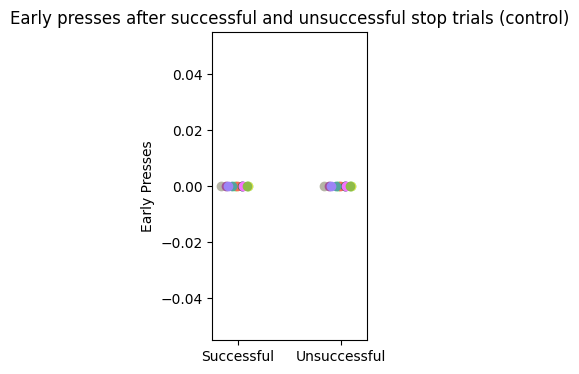

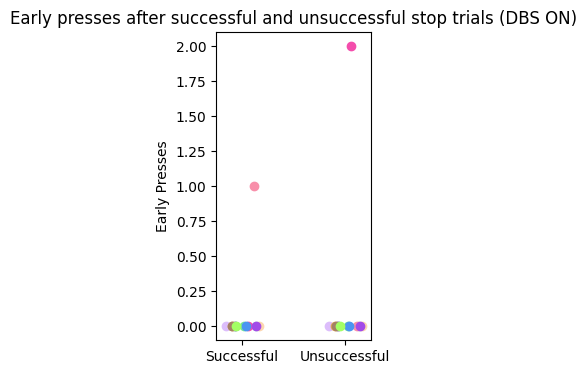

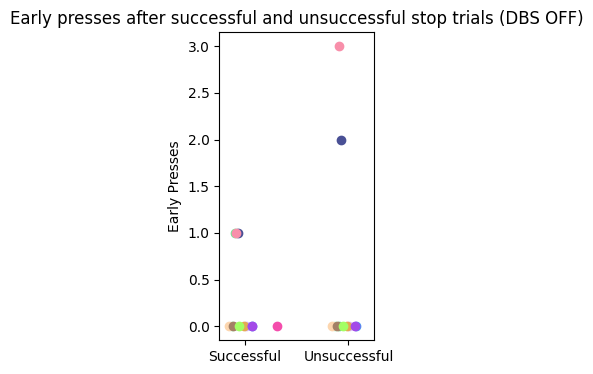

In [14]:
temp_save = os.path.join(behav_results_saving_path, 'behav after stop trials')
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
for condition in ['control', 'DBS ON', 'DBS OFF']:
    early_presses_successful = list(early_presses_by_condition['early_presses_after_successful'][condition].values())
    early_presses_unsuccessful = list(early_presses_by_condition['early_presses_after_unsuccessful'][condition].values())
    plt.figure(figsize=(2, 4))
    for sub in early_presses_by_condition['early_presses_after_successful'][condition].keys():
        early_press_success = early_presses_by_condition['early_presses_after_successful'][condition][sub]
        early_press_unsuccess = early_presses_by_condition['early_presses_after_unsuccessful'][condition][sub]
        # add jitter to the x-axis for better visualization
        jitter = np.random.normal(0, 0.2, 1)  #
        plt.plot(1 + jitter, early_press_success, 'o', color=subject_colors[sub], label=f'{sub} Successful' if sub not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.plot(3 + jitter, early_press_unsuccess, 'o', color=subject_colors[sub], label=f'{sub} Unsuccessful' if sub not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.xlim(0.5, 3.5)
    plt.xticks([1, 3], ['Successful', 'Unsuccessful'])
    plt.title(f'Early presses after successful and unsuccessful stop trials ({condition})')
    plt.ylabel('Early Presses')
    plt.savefig(os.path.join(temp_save, f'early_presses_after_stop_trials_{condition}.{save_as}'), format=save_as, bbox_inches='tight')
    plt.show()


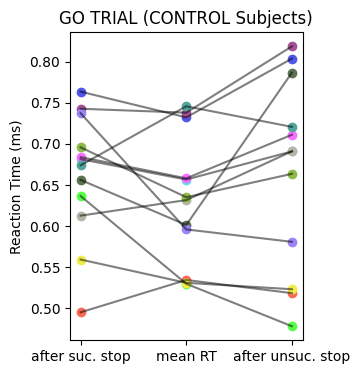

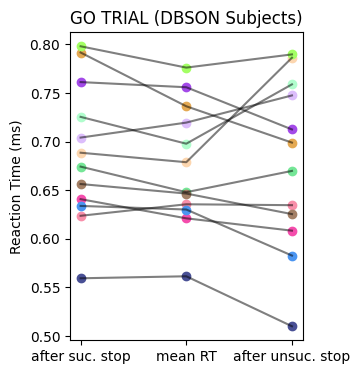

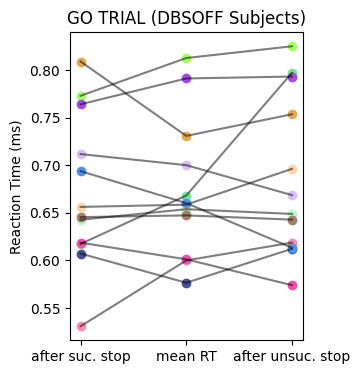

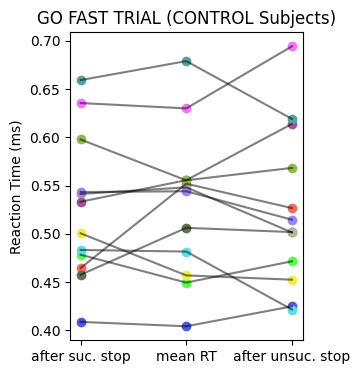

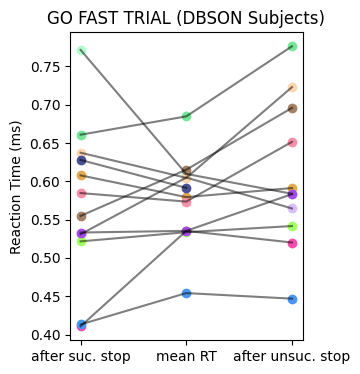

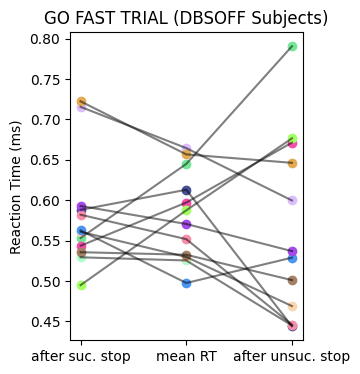

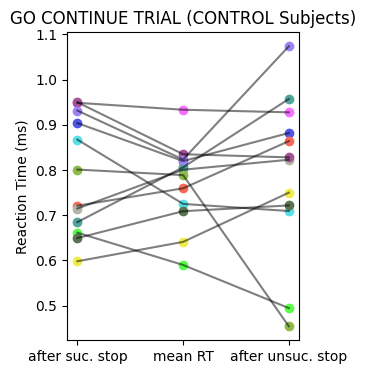

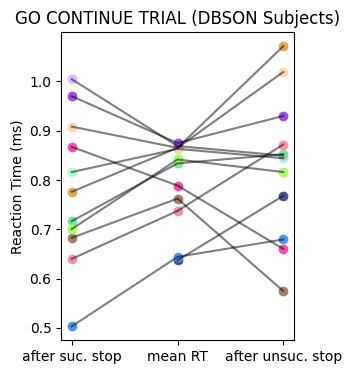

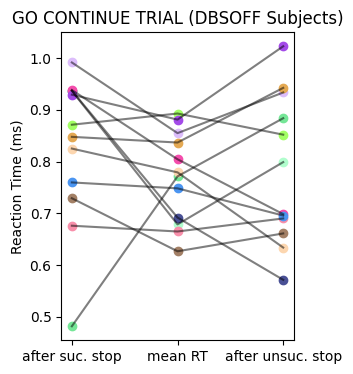

In [15]:
temp_save = os.path.join(behav_results_saving_path, 'behav after stop trials')
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
# get mean RT after unsuccessful stop for each trial type
subdivided_data_unsuccessful = {}
subdivided_data_successful = {}
for subject in included_subjects:
    subject_data = data_after_unsuccessful_stop[subject]
    unsuccessful_following = {}
    unsuccessful_following['go_trial'] = subject_data[subject_data['trial_type'] == 'go_trial']
    unsuccessful_following['stop_trial'] = subject_data[subject_data['trial_type'] == 'stop_trial']
    unsuccessful_following['go_fast_trial'] = subject_data[subject_data['trial_type'] == 'go_fast_trial']
    unsuccessful_following['go_continue_trial'] = subject_data[subject_data['trial_type'] == 'go_continue_trial']
    subdivided_data_unsuccessful[subject] = unsuccessful_following

    subject_data = data_after_successful_stop[subject]
    successful_following = {}
    successful_following['go_trial'] = subject_data[subject_data['trial_type'] == 'go_trial']
    successful_following['stop_trial'] = subject_data[subject_data['trial_type'] == 'stop_trial']
    successful_following['go_fast_trial'] = subject_data[subject_data['trial_type'] == 'go_fast_trial']
    successful_following['go_continue_trial'] = subject_data[subject_data['trial_type'] == 'go_continue_trial']
    subdivided_data_successful[subject] = successful_following
    
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}

# plot rt after successful and unsuccessful stop trials
trial_types = ['go_trial', 'go_fast_trial', 'go_continue_trial']
for trial_type in trial_types:
    for key, value in pop_dict.items():
        plt.figure(figsize=(3, 4))
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            rt_after_successful.append(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean())
            rt_after_unsuccessful.append(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean())                 
            plt.plot([1], subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean(), 'o', color= subject_colors[subject.split()[0] ])
            plt.plot([3], subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean(), 'o', color= subject_colors[subject.split()[0] ])
            plt.plot([2], mean_RT_dict[subject][trial_type], 'o', color= subject_colors[subject.split()[0] ])
        for i in range(len(value)):
            plt.plot([1, 2, 3], [rt_after_successful[i], mean_RT_dict[value[i]][trial_type], rt_after_unsuccessful[i]], 'k-', alpha=0.5)  
        plt.xticks([1, 2, 3], ['after suc. stop', 'mean RT', 'after unsuc. stop'])
        plt.ylabel('Reaction Time (ms)')
        plt.title(f'{trial_type.replace("_", " ").upper()} ({key.upper()} Subjects)')
        plt.savefig(os.path.join(temp_save, f'rt_after_successful_unsuccessful_stop_{trial_type}_{key}.{save_as}'), format=save_as, bbox_inches='tight')
        plt.show()

# 3. Post-error slowing #

### replicate classification from Li CS, Huang C, Yan P, Paliwal P, Constable RT, Sinha R. Neural correlates of post-error slowing during a stop signal task: a functional magnetic resonance imaging study. J Cogn Neurosci. 2008 Jun;20(6):1021-9. doi: 10.1162/jocn.2008.20071. PMID: 18211230; PMCID: PMC2597347.###

Classify each GO trial with a RT into:
- pG (post successful GO)
- pSS (post successful STOP)
- pSE (post unsuccessful STOP)

Do the same but separately for GF/GC trials?

In our case, we classify each GO trial with a RT as :
- pG (post successful GO)
- pSS (post successful STOP)
- pSE (post unsuccessful STOP)
- pGF (post successful GF)
- pGC (post successful GC)

In [16]:
mini_data = {}
for subject in included_subjects:
    subject_data = data[subject]
    # only keep rows from the main experiment (from the first row where 'blocks.thisRepN' is not NaN)
    subject_data = subject_data[subject_data['blocks.thisRepN'].notna()]
    mini_data[subject] = subject_data[['trial_type', 'early_press_resp.corr', 'stop_signal_time', 'key_resp_experiment.corr', 'key_resp_experiment.rt']]

for subject in included_subjects:
    sub_data = mini_data[subject]
    # create an empty list to store the new column resulting from the operation
    post = []
    for i in range(len(sub_data)):
        if i == 0:
            post.append(np.nan)  # first trial has no previous trial
        else:
            if sub_data.iloc[i]['trial_type'] == 'go_trial':
                prev_trial = sub_data.iloc[i - 1]
                if prev_trial['trial_type'] == 'stop_trial' and prev_trial['key_resp_experiment.corr'] == 0:
                    post.append('pSE')
                elif prev_trial['trial_type'] == 'stop_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pSS')
                elif prev_trial['trial_type'] == 'go_fast_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pGF')
                elif prev_trial['trial_type'] == 'go_continue_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pGC')
                elif prev_trial['trial_type'] == 'go_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pG')
                else:
                    post.append(np.nan)
            else:
                post.append(np.nan)
    sub_data['post'] = post
    mini_data[subject] = sub_data

C:\Users\Juliette\AppData\Local\Temp\ipykernel_25232\986020106.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_data['post'] = post


In [17]:
mini_data.keys()

dict_keys(['C003 mSST', 'C004 mSST', 'C006 mSST', 'C007 mSST', 'C008 mSST', 'C009 mSST', 'C010 mSST', 'C011 mSST', 'C012 mSST', 'C013 mSST', 'C014 mSST', 'C015 mSST', 'sub006 DBS ON mSST', 'sub006 DBS OFF mSST', 'sub011 DBS OFF mSST', 'sub011 DBS ON mSST', 'sub012 DBS ON mSST', 'sub012 DBS OFF mSST', 'sub015 DBS OFF mSST', 'sub015 DBS ON mSST', 'sub019 DBS ON mSST', 'sub019 DBS OFF mSST', 'sub023 DBS OFF mSST', 'sub023 DBS ON mSST', 'sub025 DBS ON mSST', 'sub025 DBS OFF mSST', 'sub027 DBS ON mSST', 'sub027 DBS OFF mSST', 'sub028 DBS OFF mSST', 'sub028 DBS ON mSST', 'sub029 DBS ON mSST', 'sub029 DBS OFF mSST', 'sub032 DBS ON mSST', 'sub032 DBS OFF mSST', 'sub033 DBS ON mSST', 'sub033 DBS OFF mSST'])

In [18]:
mini_data['C003 mSST'][0:40]

,trial_type,early_press_resp.corr,stop_signal_time,key_resp_experiment.corr,key_resp_experiment.rt,post
38,stop_trial,0.0,0.125,1.0,NaN,NaN
39,go_continue_trial,0.0,NaN,1.0,0.570173,NaN
40,go_trial,0.0,NaN,1.0,0.621220,pGC
41,go_trial,0.0,NaN,1.0,0.339435,pG
42,go_trial,0.0,NaN,1.0,0.328407,pG
43,go_fast_trial,0.0,NaN,1.0,0.326239,NaN
44,go_trial,0.0,NaN,1.0,0.468939,pGF
45,stop_trial,0.0,0.075,1.0,NaN,NaN
46,go_trial,0.0,NaN,1.0,0.315489,pSS
47,go_continue_trial,0.0,NaN,1.0,0.539518,NaN


In [19]:
# create a new column to discriminate pSSi from pSSni and pSEi from pSEni. Rule is:
# if pSS/pSE RT > RT from all previous pG, then pSSi/pSEi 
# if pSS/pSE RT < RT from all previous pG, then pSSni/pSEni
# --> basically, if the RT after a successful or unsuccessful stop trial is greater than the mean RT of all previous go trials, then it is considered an increase (i), otherwise it is considered not increased (ni)

for subject in included_subjects:
    sub_data = mini_data[subject]
    # create an empty list to store the new column resulting from the operation
    post_increase_notincreased = np.empty(len(sub_data), dtype=object).tolist()
    # print(len(sub_data))
    for i in range(len(sub_data)):
        # print(sub_data.iloc[i]['post'])
        if sub_data.iloc[i]['post'] == 'pSS':
            current_rt = sub_data.iloc[i]['key_resp_experiment.rt']
            previous_pG_rts = sub_data[(sub_data.index < i) & (sub_data['post'] == 'pG')]['key_resp_experiment.rt']
            if len(previous_pG_rts) == 0:
                continue  # no previous pG trials to compare with
            if current_rt > np.nanmean(previous_pG_rts):
                post_increase_notincreased[i] = 'pSSi'
            else:
                post_increase_notincreased[i] = 'pSSni'
        elif sub_data.iloc[i]['post'] == 'pSE':
            current_rt = sub_data.iloc[i]['key_resp_experiment.rt']
            previous_pG_rts = sub_data[(sub_data.index < i) & (sub_data['post'] == 'pG')]['key_resp_experiment.rt']
            if len(previous_pG_rts) == 0:
                continue  # no previous pG trials to compare with
            if current_rt > np.nanmean(previous_pG_rts):
                post_increase_notincreased[i] = 'pSEi'
            else:
                post_increase_notincreased[i] = 'pSEni'
        # else:
        #     post_increase_notincreased[i] = np.nan
    # print(len(post_increase_notincreased))
    sub_data['i_ni'] = post_increase_notincreased
    mini_data[subject] = sub_data


C:\Users\Juliette\AppData\Local\Temp\ipykernel_25232\3754469463.py:27: RuntimeWarning: Mean of empty slice
  if current_rt > np.nanmean(previous_pG_rts):
C:\Users\Juliette\AppData\Local\Temp\ipykernel_25232\3754469463.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_data['i_ni'] = post_increase_notincreased


In [20]:
mini_data['C010 mSST']['i_ni'].value_counts()

pSSi     15
pSSni     5
pSEi      5
pSEni     4
Name: i_ni, dtype: int64

In [21]:
values = mini_data['sub006 DBS OFF mSST']['i_ni'].value_counts()

In [22]:
all_pSEi = []
all_pSEni = []
all_pSSi = []
all_pSSni = []
all_sub_dict_i_ni = {}  
for subject in included_subjects:
    sub_dict = {}
    values = mini_data[subject]['i_ni'].value_counts()
    if 'pSEi' in values:
        all_pSEi.append(values['pSEi'])
        sub_dict['pSEi'] = values['pSEi']
    else:
        all_pSEi.append(np.nan)
        sub_dict['pSEi'] = 0
    if 'pSEni' in values:
        all_pSEni.append(values['pSEni'])
        sub_dict['pSEni'] = values['pSEni']
    else:
        all_pSEni.append(np.nan)
        sub_dict['pSEni'] = 0
    if 'pSSi' in values:
        all_pSSi.append(values['pSSi'])
        sub_dict['pSSi'] = values['pSSi']
    else:
        all_pSSi.append(np.nan)
        sub_dict['pSSi'] = 0
    if 'pSSni' in values:
        all_pSSni.append(values['pSSni'])
        sub_dict['pSSni'] = values['pSSni']
    else:
        all_pSSni.append(np.nan)
        sub_dict['pSSni'] = 0
    all_sub_dict_i_ni[subject] = sub_dict

In [24]:
# extract same values but in percent:
all_pSEi_percent = []
all_pSEni_percent = []
all_pSSi_percent = []
all_pSSni_percent = []
all_sub_dict_i_ni_percent = {}  
for subject in included_subjects:
    sub_dict = {}
    values = mini_data[subject]['i_ni'].value_counts()
    if 'pSEi' in values:
        if 'pSEni' in values:
            total_pSE = values['pSEi'] + values['pSEni']
        else:
            total_pSE = values['pSEi']
        all_pSEi_percent.append((values['pSEi'] / total_pSE) * 100)
        sub_dict['pSEi'] = (values['pSEi'] / total_pSE) * 100
    else:
        all_pSEi_percent.append(0)
        sub_dict['pSEi'] = 0
    if 'pSEni' in values:
        if 'pSEi' in values:
            total_pSE = values['pSEi'] + values['pSEni']
        else:
            total_pSE = values['pSEni']
        all_pSEni_percent.append((values['pSEni'] / total_pSE) * 100)
        sub_dict['pSEni'] = (values['pSEni'] / total_pSE) * 100
    else:
        all_pSEni_percent.append(0)
        sub_dict['pSEni'] = 0
    if 'pSSi' in values:
        if 'pSSni' in values:
            total_pSS = values['pSSi'] + values['pSSni']
        else:
            total_pSS = values['pSSi']
        all_pSSi_percent.append((values['pSSi'] / total_pSS) * 100)
        sub_dict['pSSi'] = (values['pSSi'] / total_pSS) * 100
    else:
        all_pSSi_percent.append(0)
        sub_dict['pSSi'] = 0
    if 'pSSni' in values:
        if 'pSSi' in values:
            total_pSS = values['pSSi'] + values['pSSni']
        else:
            total_pSS = values['pSSni']
        all_pSSni_percent.append((values['pSSni'] / total_pSS) * 100)
        sub_dict['pSSni'] = (values['pSSni'] / total_pSS) * 100
    else:
        all_pSSni_percent.append(0)
        sub_dict['pSSni'] = 0
    all_sub_dict_i_ni_percent[subject] = sub_dict


CONTROL
n = 12
Wilcoxon signed-rank test: W = 17.00, p = 0.2845
Significance: ns


c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


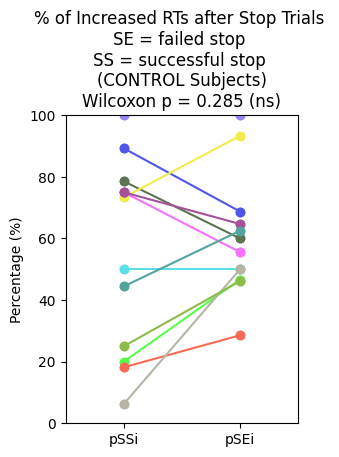


DBSON
n = 12
Wilcoxon signed-rank test: W = 37.00, p = 0.9097
Significance: ns


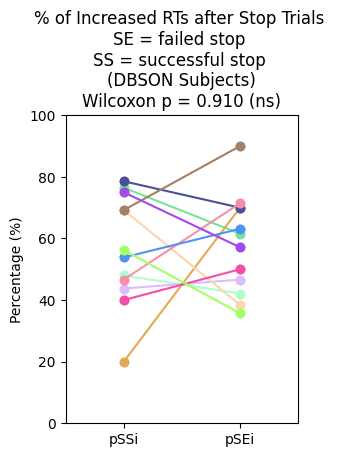


DBSOFF
n = 12
Wilcoxon signed-rank test: W = 25.00, p = 0.3013
Significance: ns


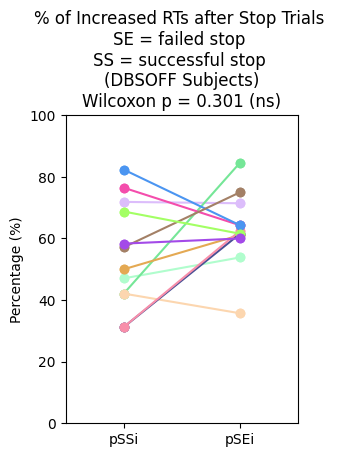

In [ ]:
from scipy.stats import wilcoxon

# plot percentage of i vs ni for each population
for key, value in pop_dict.items():
    plt.figure(figsize=(3, 4))
    pSEi_percent = []
    pSSi_percent = []

    for subject in value:
        pSEi_percent.append(all_sub_dict_i_ni_percent[subject]['pSEi'])
        pSSi_percent.append(all_sub_dict_i_ni_percent[subject]['pSSi'])
        pSSi = all_sub_dict_i_ni_percent[subject]['pSSi']
        pSEi = all_sub_dict_i_ni_percent[subject]['pSEi']
        color = subject_colors[subject.split()[0]]

        plt.plot([1, 2], [pSSi, pSEi], 'o-', color=color)
        plt.plot([2], all_sub_dict_i_ni_percent[subject]['pSEi'], 'o',
                 color=subject_colors[subject.split()[0]])
        plt.plot([1], all_sub_dict_i_ni_percent[subject]['pSSi'], 'o',
                 color=subject_colors[subject.split()[0]])

    # ---------------------------------------------------------
    # Statistical test: paired non-parametric comparison
    # ---------------------------------------------------------
    stat, p_value = wilcoxon(pSEi_percent, pSSi_percent)

    print(f'\n{key.upper()}')
    print(f'n = {len(pSEi_percent)}')
    print(f'Wilcoxon signed-rank test: W = {stat:.2f}, p = {p_value:.4f}')

    # Optional significance label
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    print(f'Significance: {significance}')

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    df_plot = pd.DataFrame({
        'pSEi': pSEi_percent,
        'pSSi': pSSi_percent,
    })

    df_melted = df_plot.melt(
        var_name='Condition',
        value_name='Percentage'
    )

    plt.title(
        f'% of Increased RTs after Stop Trials \n'
        f'SE = failed stop \n'
        f'SS = successful stop \n'
        f'({key.upper()} Subjects)\n'
        f'Wilcoxon p = {p_value:.3f} ({significance})'
    )
    plt.ylabel('Percentage (%)')
    plt.xticks([1, 2], ['pSSi', 'pSEi'])
    plt.xlim(0.5, 2.5)
    plt.ylim(0, 100)

    plt.savefig(
        os.path.join(
            temp_save,
            f'percentage_increased_RT_after_stop_{key}.{save_as}'
        ),
        format=save_as,
        bbox_inches='tight'
    )
    plt.show()

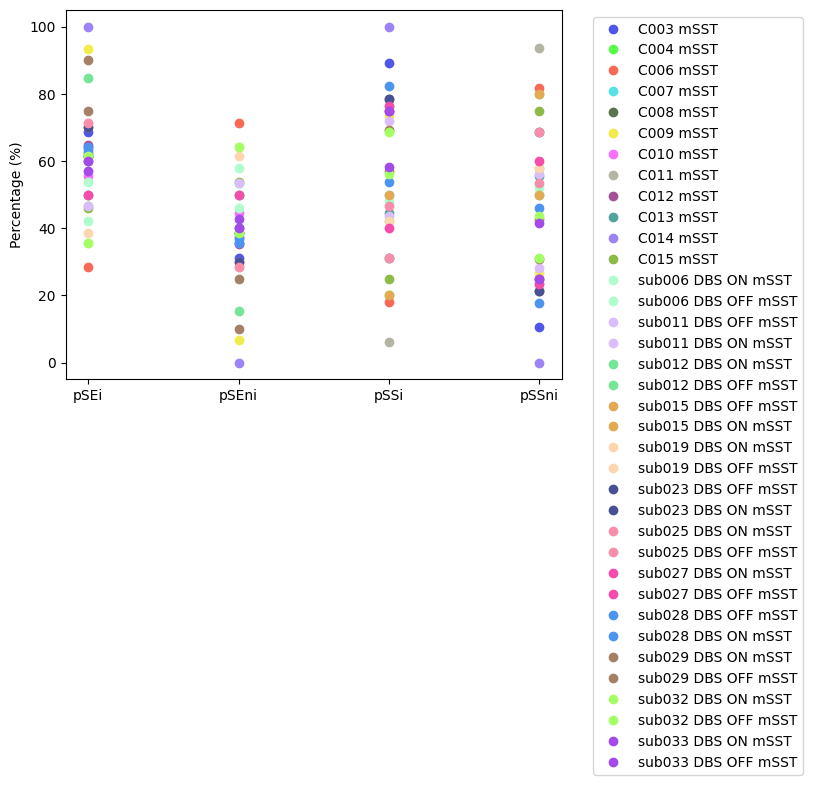

In [29]:
temp_save = os.path.join(behav_results_saving_path, 'behav after stop trials', 'post-error slowing')
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
for key, value in all_sub_dict_i_ni_percent.items():
    plt.plot(value.keys(), value.values(), 'o', color = subject_colors[key.split()[0]])

plt.ylabel('Percentage (%)')
plt.legend(all_sub_dict_i_ni_percent.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(temp_save, f'percentage_increased_RT_after_stop_all_subjects.{save_as}'), format=save_as, bbox_inches='tight')

c:\Users\Juliette\anaconda3\envs\ephy\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "



ALL SUBJECTS
n = 36
Wilcoxon signed-rank test: W = 218.50, p = 0.1768
Significance: ns


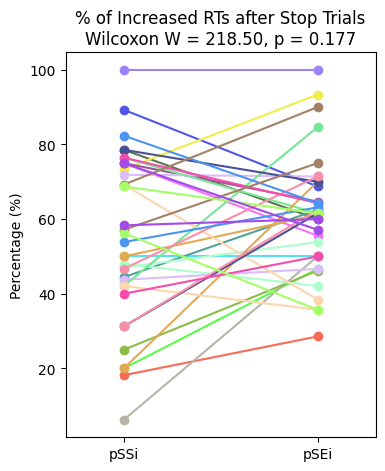

In [40]:

from scipy.stats import wilcoxon

temp_save = os.path.join(
    behav_results_saving_path,
    'behav after stop trials',
    'post-error slowing'
)

if not os.path.isdir(temp_save):
    os.makedirs(temp_save)

# ---------------------------------------------------------
# Extract paired data
# ---------------------------------------------------------
pSEi_percent = []
pSSi_percent = []

for key, value in all_sub_dict_i_ni_percent.items():
    pSEi = value['pSEi']
    pSSi = value['pSSi']

    pSEi_percent.append(pSEi)
    pSSi_percent.append(pSSi)

# ---------------------------------------------------------
# Wilcoxon signed-rank test
# ---------------------------------------------------------
stat, p_value = wilcoxon(pSEi_percent, pSSi_percent)

print('\nALL SUBJECTS')
print(f'n = {len(pSEi_percent)}')
print(f'Wilcoxon signed-rank test: W = {stat:.2f}, p = {p_value:.4f}')

# Significance label
if p_value < 0.001:
    significance = '***'
elif p_value < 0.01:
    significance = '**'
elif p_value < 0.05:
    significance = '*'
else:
    significance = 'ns'

print(f'Significance: {significance}')

# ---------------------------------------------------------
# Plot individual subjects
# ---------------------------------------------------------
plt.figure(figsize=(4, 5))

for key, value in all_sub_dict_i_ni_percent.items():

    pSSi = value['pSSi']
    pSEi = value['pSEi']

    color = subject_colors[key.split()[0]]

    # Plot paired points and connect them
    plt.plot(
        [1, 2],
        [pSSi, pSEi],
        'o-',
        color=color
    )

# ---------------------------------------------------------
# Add statistical result to plot
# ---------------------------------------------------------
y_max = max(pSSi_percent + pSEi_percent)

# Put significance above the data
# line_y = min(105, y_max + 5)
# text_y = min(112, y_max + 8)

# plt.plot(
#     [1, 1, 2, 2],
#     [line_y - 1, line_y, line_y, line_y - 1],
#     color='black'
# )

plt.ylabel('Percentage (%)')
plt.xticks([1, 2], ['pSSi', 'pSEi'])
plt.xlim(0.7, 2.3)
# plt.ylim(0, max(115, text_y + 5))

plt.title(
    f'% of Increased RTs after Stop Trials\n'
    f'Wilcoxon W = {stat:.2f}, p = {p_value:.3f}'
    )

plt.savefig(
    os.path.join(
        temp_save,
        f'percentage_increased_RT_after_stop_all_subjects.{save_as}'
    ),
    format=save_as,
    bbox_inches='tight'
)

plt.show()


In [41]:
# extract RT of go_trials that are pG, pSS, and pSE
pG_RT_all = {}
pSS_RT_all = {}
pSE_RT_all = {}
for subject in included_subjects:
    sub_data = mini_data[subject]
    pG_trials = sub_data[(sub_data['post'] == 'pG')]
    pG_RT_all[subject] = pG_trials['key_resp_experiment.rt'].tolist()
    pSS_trials = sub_data[(sub_data['post'] == 'pSS')]
    pSS_RT_all[subject] = pSS_trials['key_resp_experiment.rt'].tolist()
    pSE_trials = sub_data[(sub_data['post'] == 'pSE')]
    pSE_RT_all[subject] = pSE_trials['key_resp_experiment.rt'].tolist()


In [42]:
mean_pG_RT = {}
mean_pSS_RT = {}
mean_pSE_RT = {}
for subject in included_subjects:
    mean_pG_RT[subject] = np.nanmean(pG_RT_all[subject])
    mean_pSS_RT[subject] = np.nanmean(pSS_RT_all[subject])
    mean_pSE_RT[subject] = np.nanmean(pSE_RT_all[subject])

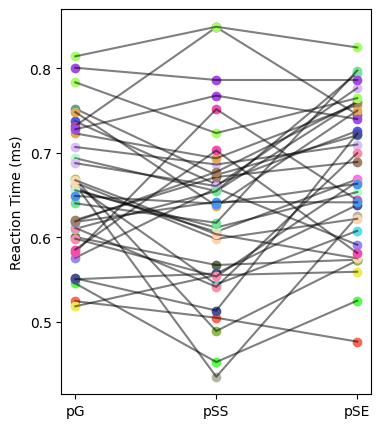

In [43]:
# plot mean RT for pG, pSS, pSE
conditions = ['pG', 'pSS', 'pSE']
plt.figure(figsize=(4, 5))
for subject in included_subjects:
    plt.plot([1], mean_pG_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
    plt.plot([2], mean_pSS_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
    plt.plot([3], mean_pSE_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
    plt.plot([1, 2, 3], [mean_pG_RT[subject], mean_pSS_RT[subject], mean_pSE_RT[subject]], 'k-', alpha=0.5)  
plt.xticks([1, 2, 3], ['pG', 'pSS', 'pSE'])
plt.ylabel('Reaction Time (ms)')
# plt.title(f'Mean RT after trial type ({key.upper()} Subjects)')
plt.show()


CONTROL SUBJECTS
n = 12
pSS vs pG: W = 19.00, p = 0.1294, Holm-corrected p = 0.2197
pSE vs pG: W = 18.00, p = 0.1099, Holm-corrected p = 0.2197


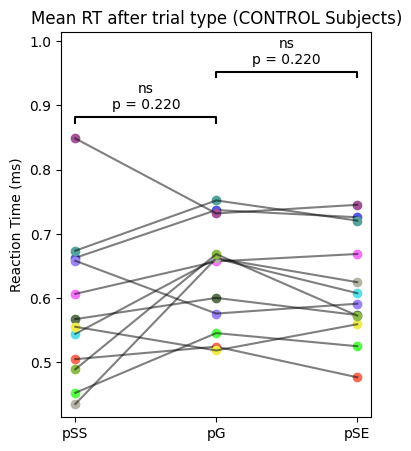


DBSON SUBJECTS
n = 12
pSS vs pG: W = 34.00, p = 0.7334, Holm-corrected p = 0.7334
pSE vs pG: W = 10.00, p = 0.0210, Holm-corrected p = 0.0420


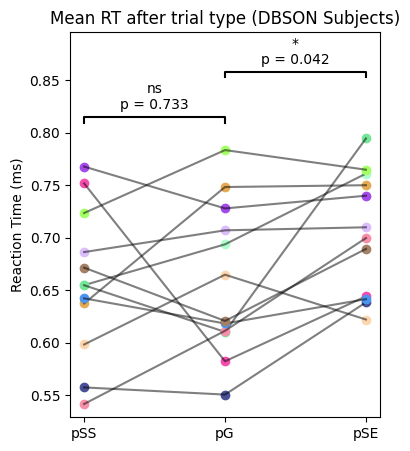


DBSOFF SUBJECTS
n = 12
pSS vs pG: W = 28.00, p = 0.4238, Holm-corrected p = 0.4238
pSE vs pG: W = 17.00, p = 0.0923, Holm-corrected p = 0.1846


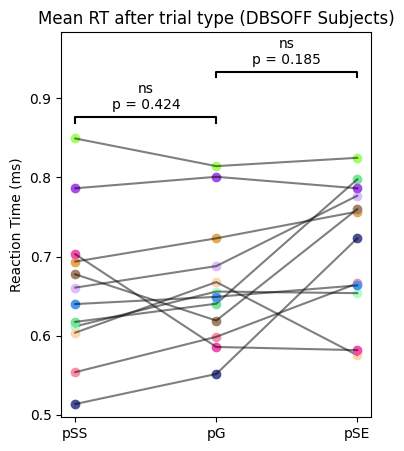

In [47]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

temp_save = os.path.join(
    behav_results_saving_path,
    'behav after stop trials',
    'post-error slowing'
)

# separate by population
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}

for key, value in pop_dict.items():

    plt.figure(figsize=(4, 5))

    # ---------------------------------------------------------
    # Collect paired data
    # ---------------------------------------------------------
    pSS = []
    pG = []
    pSE = []

    for subject in value:
        pSS.append(mean_pSS_RT[subject])
        pG.append(mean_pG_RT[subject])
        pSE.append(mean_pSE_RT[subject])

        # Plot individual subjects
        color = subject_colors[subject.split()[0]]

        plt.plot([1], mean_pSS_RT[subject], 'o', color=color)
        plt.plot([2], mean_pG_RT[subject], 'o', color=color)
        plt.plot([3], mean_pSE_RT[subject], 'o', color=color)

        # Connect measurements within subject
        plt.plot(
            [1, 2, 3],
            [
                mean_pSS_RT[subject],
                mean_pG_RT[subject],
                mean_pSE_RT[subject]
            ],
            'k-',
            alpha=0.5
        )

    # ---------------------------------------------------------
    # Statistical tests
    # ---------------------------------------------------------
    # pSS vs pG
    stat_SS_G, p_SS_G = wilcoxon(pSS, pG)

    # pSE vs pG
    stat_SE_G, p_SE_G = wilcoxon(pSE, pG)

    # Correct the two p-values for multiple comparisons
    p_values = [p_SS_G, p_SE_G]
    _, p_corrected, _, _ = multipletests(
        p_values,
        method='holm'
    )

    p_SS_G_corr = p_corrected[0]
    p_SE_G_corr = p_corrected[1]

    # ---------------------------------------------------------
    # Print results
    # ---------------------------------------------------------
    print(f'\n{key.upper()} SUBJECTS')
    print(f'n = {len(value)}')

    print(
        f'pSS vs pG: '
        f'W = {stat_SS_G:.2f}, '
        f'p = {p_SS_G:.4f}, '
        f'Holm-corrected p = {p_SS_G_corr:.4f}'
    )

    print(
        f'pSE vs pG: '
        f'W = {stat_SE_G:.2f}, '
        f'p = {p_SE_G:.4f}, '
        f'Holm-corrected p = {p_SE_G_corr:.4f}'
    )

    # ---------------------------------------------------------
    # Significance helper
    # ---------------------------------------------------------
    def get_significance(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'ns'

    sig_SS_G = get_significance(p_SS_G_corr)
    sig_SE_G = get_significance(p_SE_G_corr)

    # ---------------------------------------------------------
    # Add significance brackets to plot
    # ---------------------------------------------------------
    y_max = max(pSS + pG + pSE)
    y_range = max(pSS + pG + pSE) - min(pSS + pG + pSE)

    # Avoid problems if all values are very similar
    if y_range == 0:
        y_range = 10

    # First comparison: pSS vs pG
    y1 = y_max + 0.08 * y_range

    plt.plot(
        [1, 1, 2, 2],
        [y1 - 0.02*y_range, y1, y1, y1 - 0.02*y_range],
        'k-'
    )

    plt.text(
        1.5,
        y1 + 0.02*y_range,
        f'{sig_SS_G}\np = {p_SS_G_corr:.3f}',
        ha='center',
        va='bottom'
    )

    # Second comparison: pSE vs pG
    y2 = y_max + 0.25 * y_range

    plt.plot(
        [2, 2, 3, 3],
        [y2 - 0.02*y_range, y2, y2, y2 - 0.02*y_range],
        'k-'
    )

    plt.text(
        2.5,
        y2 + 0.02*y_range,
        f'{sig_SE_G}\np = {p_SE_G_corr:.3f}',
        ha='center',
        va='bottom'
    )

    # ---------------------------------------------------------
    # Plot formatting
    # ---------------------------------------------------------
    plt.xticks([1, 2, 3], ['pSS', 'pG', 'pSE'])
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'Mean RT after trial type ({key.upper()} Subjects)')

    plt.ylim(
        min(pSS + pG + pSE) - 0.05*y_range,
        y2 + 0.15*y_range
    )

    plt.savefig(
        os.path.join(
            temp_save,
            f'mean_RT_after_trial_type_{key}.{save_as}'
        ),
        format=save_as,
        bbox_inches='tight'
    )
    plt.show()


"Our observers exhibited a robust post-stop error slowing effect: RTs were significantly slower on pSE trials compared to pG trials (570 ± 127 vs. 528 ± 121 msec, mean ± SD; p < .001, paired t test; Figure 1C), suggesting that they implemented appropriate error monitoring and adjusted behaviors accordingly (Rabbit, 1966). Importantly, although observers were generally slower responding after an error, individual participants demonstrated significant trial-to-trial variation in pSE slowing"

Paired t-test between pSS and pSE trials for control subjects: t=1.472120976813849, p=0.08450650918089779


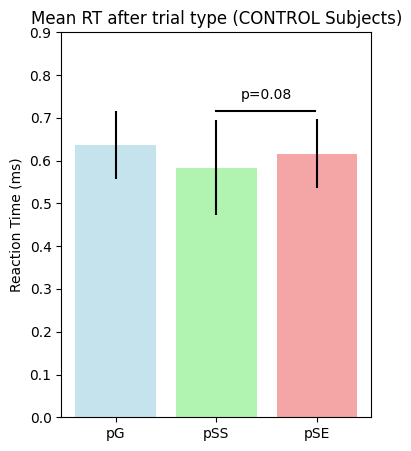

Paired t-test between pSS and pSE trials for dbson subjects: t=2.1562024600733527, p=0.027030216254729414


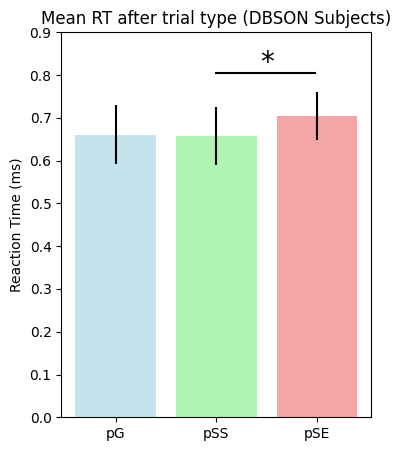

Paired t-test between pSS and pSE trials for dbsoff subjects: t=2.024716794567235, p=0.03393210905338292


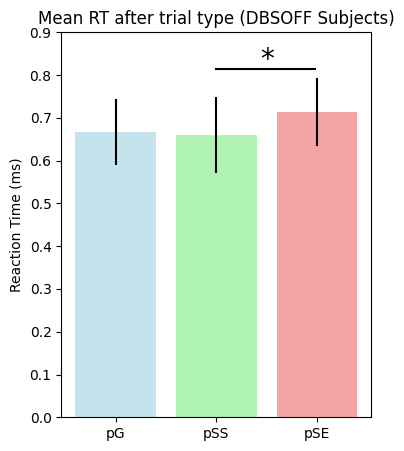

In [50]:
temp_save = os.path.join(
    behav_results_saving_path,
    'behav after stop trials',
    'post-error slowing'
)
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
# do a barplot with mean and std error
# separate by population
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}

for key, value in pop_dict.items():
    plt.figure(figsize=(4, 5))
    mean_pG_RT_temp = []
    mean_pSS_RT_temp = []
    mean_pSE_RT_temp = []
    for subject in value:
        mean_pG_RT_temp.append(mean_pG_RT[subject])
        mean_pSS_RT_temp.append(mean_pSS_RT[subject])
        mean_pSE_RT_temp.append(mean_pSE_RT[subject])
    plt.bar([1, 2, 3], [np.mean(mean_pG_RT_temp), np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)], 
            yerr=[np.std(mean_pG_RT_temp), np.std(mean_pSS_RT_temp), np.std(mean_pSE_RT_temp)],
            color=['lightblue', 'lightgreen', 'lightcoral'], alpha=0.7)
    # Hypothesis: H0: pSZ RT > pSS RT (post-error slowing)
    # paired t-test between pSS and pSE trials:
    t_stat, p_value = ttest_rel(mean_pSE_RT_temp, mean_pSS_RT_temp, alternative = 'greater', nan_policy='omit')
    print(f'Paired t-test between pSS and pSE trials for {key} subjects: t={t_stat}, p={p_value}')
    # add significance asterisks
    if p_value < 0.05:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.09, '*', ha='center', va='bottom', fontsize=20)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    elif p_value < 0.01:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.09, '**', ha='center', va='bottom', fontsize=20)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    elif p_value < 0.001:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.09, '***', ha='center', va='bottom', fontsize=20)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    elif p_value < 0.1:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.12, f"p={p_value:.2f}", ha='center', va='bottom', fontsize=10)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    plt.xticks([1, 2, 3], ['pG', 'pSS', 'pSE'])
    plt.ylim(0, 0.9)
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'Mean RT after trial type ({key.upper()} Subjects)')
    plt.savefig(
        os.path.join(
            temp_save,
            f'mean_RT_after_trial_type_barplot_{key}.{save_as}'
        ),
        format=save_as,
        bbox_inches='tight'
    )
    plt.show()

# 4. Other ways of plotting #

In [51]:
# compute group level mean statistics

group_stats = {}
for trial_type in trial_types:
    group_stats[trial_type] = {}
    for key, value in pop_dict.items():
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            if np.isnan(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean()) or np.isnan(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean()):
                continue
            rt_after_successful.append(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean())
            rt_after_unsuccessful.append(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean())
        mean_rt_successful = np.nanmean(rt_after_successful)
        mean_rt_unsuccessful = np.nanmean(rt_after_unsuccessful)
        stat, p_value = ttest_rel(rt_after_successful, rt_after_unsuccessful)
        group_stats[trial_type][key] = {
            'mean_rt_after_successful': mean_rt_successful,
            'mean_rt_after_unsuccessful': mean_rt_unsuccessful,
            'ttest_stat': stat,
            'p_value': p_value
        }
group_stats

{'go_trial': {'control': {'mean_rt_after_successful': 0.6615678189284421,
   'mean_rt_after_unsuccessful': 0.6656047763426737,
   'ttest_stat': -0.1581502073966328,
   'p_value': 0.8772043684060852},
  'dbson': {'mean_rt_after_successful': 0.6880993690004805,
   'mean_rt_after_unsuccessful': 0.6770530886176772,
   'ttest_stat': 0.7412342203316573,
   'p_value': 0.4740789905969992},
  'dbsoff': {'mean_rt_after_successful': 0.6726432994719037,
   'mean_rt_after_unsuccessful': 0.6871340322085336,
   'ttest_stat': -0.7015794728783321,
   'p_value': 0.4975165266352515}},
 'go_fast_trial': {'control': {'mean_rt_after_successful': 0.5252601000325985,
   'mean_rt_after_unsuccessful': 0.5258573714451941,
   'ttest_stat': -0.0416732161807258,
   'p_value': 0.9675060050973605},
  'dbson': {'mean_rt_after_successful': 0.5660409881820972,
   'mean_rt_after_unsuccessful': 0.6070582536122388,
   'ttest_stat': -1.529583656168669,
   'p_value': 0.157115623098948},
  'dbsoff': {'mean_rt_after_successful

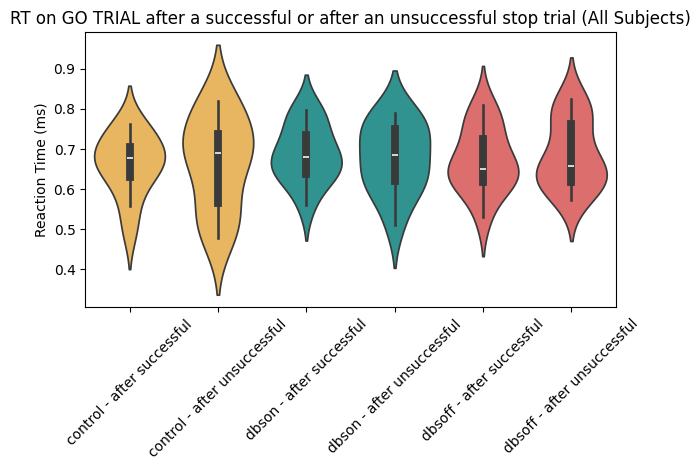

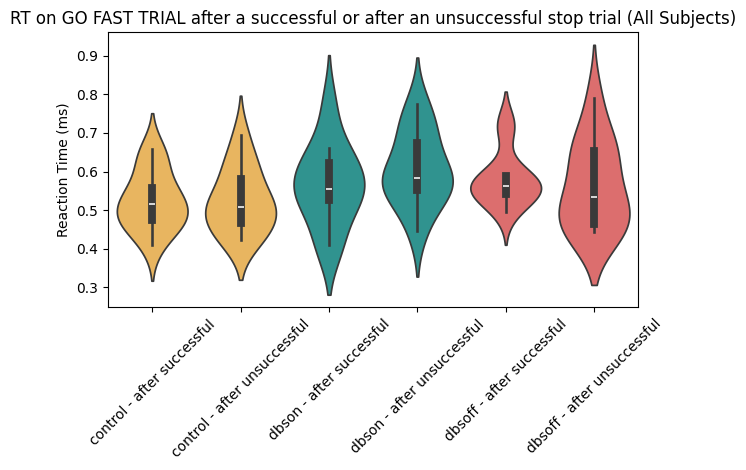

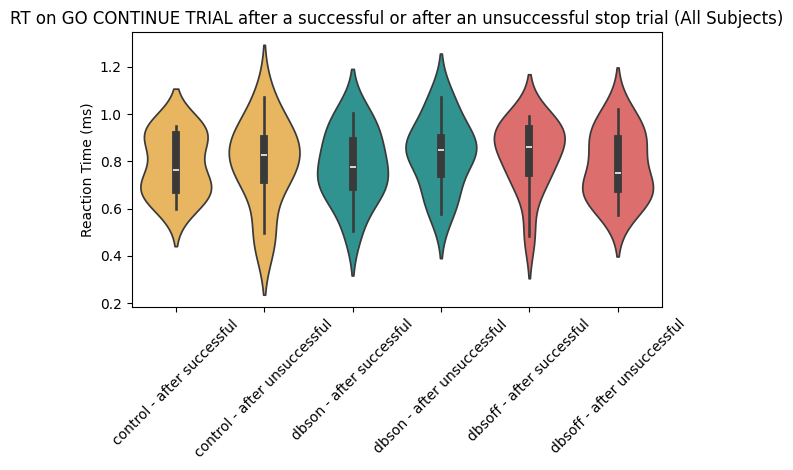

In [97]:
# create a figure summarizing the results with violin plots
for trial_type in trial_types:
    plt.figure()
    summary_data = []
    labels = []
    for key, value in pop_dict.items():
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            if np.isnan(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean()) or np.isnan(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean()):
                continue
            rt_after_successful.append(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean())
            rt_after_unsuccessful.append(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean())
        summary_data.append(rt_after_successful)
        labels.append(f'{key} - after successful')
        summary_data.append(rt_after_unsuccessful)
        labels.append(f'{key} - after unsuccessful')

    # color code based on population
    colors = [color_dict[key.lower()] for key in pop_dict.keys() for _ in (0, 1)]
    sns.violinplot(data=summary_data, palette=colors)
    plt.xticks(np.arange(len(labels)), labels, rotation=45)
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'RT on {trial_type.replace("_", " ").upper()} after a successful or after an unsuccessful stop trial (All Subjects)')
    plt.tight_layout()
    plt.show()